# 07 · 赛中实时采集 V3（模拟快照 + 真实采集）

## 这个 notebook 在做什么？

前面 05/06 我们做的是**赛前预测**——比赛开始前，用战队历史、BP 阵容去猜谁赢。那种模型的上限很有限，因为信息太少。

真正有价值的是**赛中实时预测**：比赛打到第 5 分钟，一方经济领先 3000、多拿了 2 条人头，这时候谁赢的概率更大？

要做赛中预测，第一步就是**拿到赛中数据**——也就是比赛进行中不同时间点的快照（snapshot）。

### 问题来了：我们现在只有赛后数据

目前 `battles.csv` 里的 127 场比赛，都是**赛后快照**（比赛结束后的最终数据）。要拿到赛中数据，只有两种途径：

| 方案 | 思路 | 优缺点 |
|------|------|--------|
| **Track A：模拟快照** | 用已有的赛后数据，按时间比例"反推"出 3/5/8/10 分钟的近似值 | ✅ 立刻可用，127 场 × 4 个时间点 = 508 条训练数据<br>❌ 是近似值，不是真实对局走势 |
| **Track B：真实采集** | 比赛直播时，每隔 30 秒调一次 API，记录真实的赛中数据 | ✅ 真实数据，模型质量更高<br>❌ 需要等比赛直播，无法回溯历史 |

本 notebook 两条路都走：**先用 Track A 生成训练数据，让 08/09 能立刻跑起来**；同时把 Track B 的采集代码准备好，等下次有直播就能真采。

### 为什么这个设计对求职有价值？

面试官会问："你的实时数据是怎么来的？" 你可以说：

> "我设计了双轨数据采集方案：Track A 基于赛后数据按时间比例模拟快照用于模型冷启动，
> Track B 利用赛事 API 在直播时实时采集。模拟数据让我快速验证了建模思路，
> 真实数据采上来后可以直接替换，模型代码零改动。"

这体现了**工程落地能力**——不等完美数据，先用近似方案跑通全链路。

---
## 步骤 0 · 导包与配置

沿用项目已有的 `src/config.py` 路径管理，保持一致性。

In [2]:
import sys
from pathlib import Path

# 将项目根目录加入 sys.path，这样可以 import src 下的模块
PROJECT_ROOT = Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

from src.config import PROCESSED_DIR, RAW_DIR, OUTPUT_DIR, BASE_URL_BATTLE, HEADERS, TIMEOUT, MAX_RETRY, SLEEP_RANGE

# 实时数据专用目录
REALTIME_DIR = PROJECT_ROOT / "data" / "realtime"
REALTIME_DIR.mkdir(parents=True, exist_ok=True)

print(f"项目根目录: {PROJECT_ROOT}")
print(f"赛后数据目录: {PROCESSED_DIR}")
print(f"实时数据目录: {REALTIME_DIR}")

项目根目录: D:\AI数据分析\项目作品集\02-KPL实时胜率预测系统
赛后数据目录: D:\AI数据分析\项目作品集\02-KPL实时胜率预测系统\data\processed
实时数据目录: D:\AI数据分析\项目作品集\02-KPL实时胜率预测系统\data\realtime


In [3]:
# ═══════════════════════════════════════════════════════════════
# 决策点 1.1：定义快照的 Schema 和时间切片
# ═══════════════════════════════════════════════════════════════
#
# 💡 你需要思考的问题：
#
#   "一条快照需要哪些列？"
#
# 思维过程：
#   1. 标识信息 — 这条快照属于哪场比赛、哪个时间点
#   2. 局势信息 — 双方当前的经济/人头/推塔/暴君
#   3. 差值信息 — 直接算好的差（模型特征的核心输入）
#   4. 标签信息 — 这场比赛最终谁赢（注意：是最终结果，不是当前时间点的）
#   5. 元数据   — 是模拟的还是真实采集的（方便后续区分数据来源）
#
# 关于 TIME_BINS：
#   "我要在哪些时间点取快照？"
#   你需要平衡两个考虑：
#   - 太早（<3分钟）：双方几乎没区别，信息量为零
#   - 太晚（>15分钟）：很多比赛已经结束了，样本会大量缺失
#   - 间隔太密：模拟数据本身就是插值，密了也没有更多信息
#
# 📌 验证锚点：SNAPSHOT_COLS 应有 16 列
# ═══════════════════════════════════════════════════════════════

# 你来写代码
SNAPSHOT_COLS = [
	'battle_id', 'snapshot_time_sec','minute_bin',
	'camp1_gold','camp2_gold','gold_diff',
	'camp1_kill_num','camp2_kill_num',' kill_diff',
	'camp1_push_tower_num','camp2_push_tower_num','tower_diff',
	'camp1_tyrant', 'camp2_tyrant',
	'win_camp','is_simulated'
]

TIME_BINS = {
	'4min' : 240,
	'6min' : 360,
	'8min' : 480,
	'10min' : 600,
	'12min' : 720,
	'14min' : 840,
	'16min' : 960,
	'18min' : 1080,
	'20min' : 1200,
	'22min' : 1320,
	'24min' : 1440,
	'26min' : 1560,
}

print(f"快照列数: {len(SNAPSHOT_COLS)}")   # 应该是 16
print(f"时间切片: {TIME_BINS}")

快照列数: 16
时间切片: {'4min': 240, '6min': 360, '8min': 480, '10min': 600, '12min': 720, '14min': 840, '16min': 960, '18min': 1080, '20min': 1200, '22min': 1320, '24min': 1440, '26min': 1560}


---
## 步骤 1 · 设计快照 Schema

### 一条快照代表什么？

一条快照 = **某场比赛在某个时间点的状态切片**。

比如 `battle_id=736117264_10_1777089898`，在第 5 分钟（300 秒）时：
- camp1 经济 18000，camp2 经济 16500 → 经济差 +1500
- camp1 人头 4，camp2 人头 2 → 人头差 +2
- camp1 推塔 1，camp2 推塔 0 → 推塔差 +1

最终这场比赛 camp1 赢了（win_camp=1），那这条快照的标签就是 1。

### Schema 定义

| 列名 | 类型 | 说明 |
|------|------|------|
| battle_id | str | 对局 ID，关联 battles.csv |
| snapshot_time_sec | int | 快照对应的比赛时刻（秒） |
| minute_bin | str | 时间分桶："3min" / "5min" / "8min" / "10min" / "final" |
| camp1_gold | float | camp1 当前经济 |
| camp2_gold | float | camp2 当前经济 |
| gold_diff | float | 经济差（camp1 - camp2） |
| camp1_kill_num | float | camp1 当前击杀数 |
| camp2_kill_num | float | camp2 当前击杀数 |
| kill_diff | float | 人头差（camp1 - camp2） |
| camp1_push_tower_num | float | camp1 当前推塔数 |
| camp2_push_tower_num | float | camp2 当前推塔数 |
| tower_diff | float | 推塔差（camp1 - camp2） |
| camp1_tyrant | float | camp1 暴君击杀数 |
| camp2_tyrant | float | camp2 暴君击杀数 |
| win_camp | int | 最终获胜阵营（标签，1 或 2） |
| is_simulated | bool | True = Track A 模拟数据，False = Track B 真实采集 |

注意：`win_camp` 是**比赛最终结果**，不是这个时间点的结果。因为我们要用「第 N 分钟的状态」来预测「最终谁赢」。

### 为什么和 `src/realtime/snapshot_schema.py` 不完全一样？

已有的 `snapshot_schema.py` 是为 Track B 真实采集设计的，包含 `collected_at`、`status` 等采集元数据字段。
这里我们定义的是**建模用的统一 schema**——Track A 模拟和 Track B 采集最终都要对齐到这个格式，给 notebook 08 用。

In [4]:
# ═══════════════════════════════════════════════════════════════
# 决策点 1.1：定义快照的 Schema 和时间切片
# ═══════════════════════════════════════════════════════════════
#
# 💡 你需要思考的问题：
#
#   "一条快照需要哪些列？"
#
# 思维过程：
#   1. 标识信息 — 这条快照属于哪场比赛、哪个时间点
#   2. 局势信息 — 双方当前的经济/人头/推塔/暴君
#   3. 差值信息 — 直接算好的差（模型特征的核心输入）
#   4. 标签信息 — 这场比赛最终谁赢（注意：是最终结果，不是当前时间点的）
#   5. 元数据   — 是模拟的还是真实采集的（方便后续区分数据来源）
#
# 关于 TIME_BINS：
#   "我要在哪些时间点取快照？"
#   你需要平衡两个考虑：
#   - 太早（<3分钟）：双方几乎没区别，信息量为零
#   - 太晚（>15分钟）：很多比赛已经结束了，样本会大量缺失
#   - 间隔太密：模拟数据本身就是插值，密了也没有更多信息
#
# 📌 验证锚点：SNAPSHOT_COLS 应有 16 列
# ═══════════════════════════════════════════════════════════════

# 你来写代码
SNAPSHOT_COLS = [
	'battle_id', 'snapshot_time_sec','minute_bin',
	'camp1_gold','camp2_gold','gold_diff',
	'camp1_kill_num','camp2_kill_num',' kill_diff',
	'camp1_push_tower_num','camp2_push_tower_num','tower_diff',
	'camp1_tyrant', 'camp2_tyrant',
	'win_camp','is_simulated'
]

TIME_BINS = {
	'4min' : 240,
	'6min' : 360,
	'8min' : 480,
	'10min' : 600,
	'12min' : 720,
	'14min' : 840,
	'16min' : 960,
	'18min' : 1080,
	'20min' : 1200,
	'22min' : 1320,
	'24min' : 1440,
	'26min' : 1560,
}

print(f"快照列数: {len(SNAPSHOT_COLS)}")   # 应该是 16
print(f"时间切片: {TIME_BINS}")

快照列数: 16
时间切片: {'4min': 240, '6min': 360, '8min': 480, '10min': 600, '12min': 720, '14min': 840, '16min': 960, '18min': 1080, '20min': 1200, '22min': 1320, '24min': 1440, '26min': 1560}


---
## 步骤 2 · Track A：从赛后数据模拟时间序列快照

### 核心思路

已知一场比赛的**最终数据**（比赛时长 T 秒，最终经济 G，最终人头 K，最终推塔数 Tw），
我们要"反推"出第 t 秒时的值。

最简单的做法是**线性插值**：`value_at_t = final_value × (t / T)`

但实际比赛中，不同指标的增长节奏不同：

| 指标 | 增长特征 | alpha 值 | 直觉解释 |
|------|----------|----------|----------|
| 经济 (gold) | 接近线性 | 1.0 | 每分钟都有兵线 + 野怪收入 |
| 击杀 (kills) | 略微后期加速 | 1.3 | 前期对线少打架，中后期团战密集 |
| 推塔 (towers) | 明显后期密集 | 1.5 | 前期很难推塔，中后期一波团灭推好几座 |
| 暴君 (tyrant) | 接近线性 | 1.0 | 暴君刷新相对均匀 |

公式：

$$\text{value\_at\_t} = \text{final\_value} \times \left(\frac{t}{T}\right)^{\alpha}$$

### ⚠️ 这个近似有什么局限？

1. **忽略了比赛个体差异**：有的比赛前期就打出血崩，有的是后期翻盘。但模拟出来的快照永远是"平滑增长"。
2. **不存在"领先反转"**：真实比赛中经济差可能先涨后跌（被翻盘），但模拟数据里金额差的正负不会翻转。
3. **对模型的影响**：模型会学到"经济差越大越可能赢"这个大方向（这是对的），但会低估"翻盘"的可能性。

**结论**：Track A 模拟数据足够让我们**跑通 08/09 的建模流程**，但模型效果的上限取决于 Track B 真实数据的量。
在简历上要诚实地写："基于模拟数据冷启动，后续用真实采集数据迭代。"

### 2.1 加载赛后数据

In [5]:
# ═══════════════════════════════════════════════════════════════
# 决策点 2.1：加载赛后数据 — 先搞清楚你手里有什么
# ═══════════════════════════════════════════════════════════════
#
# 💡 你需要思考的问题：
#
#   "模拟快照需要用到赛后数据的哪些列？"
#
# 思维过程：
#   快照的核心是：某时间点的经济/人头/推塔/暴君。
#   赛后数据里有最终值（final），我们要从 final 反推中间值。
#   所以你需要的列是：
#     - battle_id（标识）
#     - game_duration（用来算比例 t/T）
#     - win_camp（标签）
#     - camp1/camp2 的 gold, kill_num, push_tower_num, kill_tyrant_num
#
#   另外，game_duration 的分布直接决定了你能生成多少快照：
#   如果一场比赛只打了 5 分钟（300 秒），那 8min 和 10min 的快照就不能生成。
#   所以先看分布——如果大部分比赛都超过 10 分钟，那每场都能产出 4 条快照。
#
# 📌 验证锚点：battles 应有 127 行，game_duration 中位数约 800-900 秒
# ═══════════════════════════════════════════════════════════════
#
# 代码提醒：
#   battles = pd.read_csv(PROCESSED_DIR / "battles.csv")
#   print(battles.shape[0])
#   print(battles['game_duration'].describe())
#   key_cols = ["battle_id", "game_duration", "win_camp",
#               "camp1_gold", "camp2_gold",
#               "camp1_kill_num", "camp2_kill_num",
#               "camp1_push_tower_num", "camp2_push_tower_num",
#               "camp1_kill_tyrant_num", "camp2_kill_tyrant_num"]
#   battles[key_cols].head(3)

# 你来写代码
battles = pd.read_csv(PROCESSED_DIR / "battles.csv")

In [6]:
print(battles.shape[0])
print(battles['game_duration'].describe())

127
count     127.000000
mean      893.503937
std       233.161225
min       354.000000
25%       749.000000
50%       860.000000
75%       988.000000
max      2033.000000
Name: game_duration, dtype: float64


In [7]:
key_cols = [
"battle_id", "game_duration", "win_camp",
"camp1_gold", "camp2_gold",
"camp1_kill_num", "camp2_kill_num",
"camp1_push_tower_num", "camp2_push_tower_num",
"camp1_kill_tyrant_num", "camp2_kill_tyrant_num",
]

### 2.2 编写模拟快照函数

核心函数 `simulate_snapshots_for_battle`：给定一场比赛的赛后数据行，生成 4 个时间点的模拟快照。

注意两个边界情况：
1. 如果比赛时长不足 t 秒（例如比赛只打了 400 秒，不到 8 分钟），则跳过 480s 和 600s 的快照
2. 值要取整（人头、推塔是整数），经济保留整数

In [8]:
# ═══════════════════════════════════════════════════════════════
# 决策点 2.2：设计插值函数 — "如何从终局反推中间过程？"
# ═══════════════════════════════════════════════════════════════
#
# 💡 核心问题：已知一场比赛打了 T 秒、最终经济是 G，第 t 秒时经济大概是多少？
#
# ---- 第一个决策：用什么插值模型？ ----
#
# 选项 A：线性插值 → value_at_t = final × (t / T)
#   优点：简单直观
#   缺点：不符合实际。人头不是匀速增加的——前期安全对线、中后期频繁团战
#
# 选项 B：幂律插值 → value_at_t = final × (t / T)^α
#   α = 1.0 → 等价于线性
#   α > 1.0 → 前期慢、后期快（适合人头、推塔）
#   α < 1.0 → 前期快、后期慢（暂无此类指标）
#
# 选择 B，因为不同指标的时间节奏确实不同：
#   - 经济：每分钟都有稳定兵线收入 → α ≈ 1.0
#   - 击杀：前期少打架，中后期团战密集 → α ≈ 1.3
#   - 推塔：前期几乎推不动，后期团灭一波推好几座 → α ≈ 1.5
#   - 暴君：刷新间隔大致固定 → α ≈ 1.0
#
# ---- 第二个决策：边界情况怎么处理？ ----
#
# 1. 比赛时长不足 t 秒 → 跳过该时间点（不能凭空编造）
# 2. t/T > 1 → cap 到 1.0（理论上不会发生，防御性编程）
# 3. 人头/推塔必须是整数 → round 后取 int
#
# ---- 面试怎么讲这个设计 ----
# "由于无法获取赛中逐秒数据，我用幂律插值模拟不同指标的时间增长节奏——
#  经济近似线性增长，击杀和推塔用 α>1 的幂律拟合'前期平稳、后期爆发'的特征。
#  这是一种 informed simulation：不是盲目线性，而是基于电竞比赛节奏的先验假设。"
#
# 📌 验证锚点：对第一场比赛（时长~800s）应该能生成 10+ 条快照
# ═══════════════════════════════════════════════════════════════
#
# 代码提醒：
#
# ALPHA = {"gold": 1.0, "kill": 1.3, "tower": 1.5, "tyrant": 1.0}
#
# def interpolate_value(final_value, t, total_t, alpha):
#     if total_t <= 0 or t <= 0: return 0.0
#     ratio = min(t / total_t, 1.0)
#     return final_value * (ratio ** alpha)
#
# def simulate_snapshots_for_battle(row):
#     T = row['game_duration']
#     snapshots = []
#     for label, t_sec in TIME_BINS.items():
#         if t_sec >= T:  # 比赛不够长，跳过
#             continue
#         c1_gold = round(interpolate_value(row['camp1_gold'], t_sec, T, ALPHA['gold']))
#         c2_gold = round(interpolate_value(row['camp2_gold'], t_sec, T, ALPHA['gold']))
#         c1_kill = int(round(interpolate_value(row['camp1_kill_num'], t_sec, T, ALPHA['kill'])))
#         # ... 其他字段类似
#         snap = {'battle_id': row['battle_id'], 'snapshot_time_sec': t_sec,
#                 'minute_bin': label, 'camp1_gold': c1_gold, ...
#                 'gold_diff': c1_gold - c2_gold, 'win_camp': row['win_camp'],
#                 'is_simulated': True}
#         snapshots.append(snap)
#     return snapshots
#
# # 测试：
# test_snaps = simulate_snapshots_for_battle(battles.iloc[0])
# print(f"第一场（{battles.iloc[0]['game_duration']:.0f}s）→ {len(test_snaps)} 条快照")

# 你来写代码
ALPHA = {
	"gold" : 1.0,
	"kill" : 1.3,
	"tower" : 1.5,
	"tyrant" : 1.0
}

In [9]:
def interpolate_value(final_value, t, total_t, alpha):
     if total_t <= 0 or t <= 0: return 0.0
     ratio = min(t / total_t, 1.0)
     return final_value * (ratio ** alpha)

In [10]:
def simulate_snapshots_for_battle(row):
     T = row['game_duration']
     snapshots = []
     for label, t_sec in TIME_BINS.items():
         if t_sec >= T:  # 比赛不够长，跳过
             continue
         c1_gold = round(interpolate_value(row['camp1_gold'], t_sec, T, ALPHA['gold']))
         c2_gold = round(interpolate_value(row['camp2_gold'], t_sec, T, ALPHA['gold']))
         c1_kill = int(round(interpolate_value(row['camp1_kill_num'], t_sec, T, ALPHA['kill'])))
         c2_kill = int(round(interpolate_value(row['camp1_kill_num'], t_sec, T, ALPHA['kill'])))
         c1_tower = int(round(interpolate_value(row['camp1_push_tower_num'], t_sec, T, ALPHA['kill'])))
         c2_tower = int(round(interpolate_value(row['camp2_push_tower_num'], t_sec, T, ALPHA['kill'])))

         snap = {'battle_id': row['battle_id'], 'snapshot_time_sec': t_sec,
                 'minute_bin': label, 'camp1_gold': c1_gold,
                 'gold_diff': c1_gold - c2_gold, 'win_camp': row['win_camp'],
                 'is_simulated': True,'c1_tower' : c1_tower,
                 'c1_kill' : c1_kill,'kill_diff' : c1_kill - c2_kill,
                 'tower_diff' : c1_tower - c2_tower,
                 }
         snapshots.append(snap)
     return snapshots

test_snaps = simulate_snapshots_for_battle(battles.iloc[0])
print(f"第一场（{battles.iloc[0]['game_duration']:.0f}s）→ {len(test_snaps)} 条快照")

第一场（801s）→ 5 条快照


In [11]:
pd.DataFrame(test_snaps)

,battle_id,snapshot_time_sec,minute_bin,camp1_gold,gold_diff,win_camp,is_simulated,c1_tower,c1_kill,kill_diff,tower_diff
0,736117264_100_1777617541,240,4min,11745,-2324,2,True,0,1,0,-1
1,736117264_100_1777617541,360,6min,17617,-3486,2,True,0,1,0,-2
2,736117264_100_1777617541,480,8min,23489,-4648,2,True,1,2,0,-3
3,736117264_100_1777617541,600,10min,29362,-5810,2,True,1,2,0,-4
4,736117264_100_1777617541,720,12min,35234,-6972,2,True,1,3,0,-5


### 2.3 批量生成所有比赛的模拟快照

In [12]:
# ═══════════════════════════════════════════════════════════════
# 决策点 2.3：批量生成 → 验证"数据膨胀"是否符合预期
# ═══════════════════════════════════════════════════════════════
#
# 💡 思维过程：
#
# 原始数据：127 场比赛，每场 1 行
# 模拟后：每场比赛 × N 个时间切片 = 127 × N 行
#
# 你选了多少个 TIME_BINS？如果是 12 个（4min~26min），理论上最多 127×12=1524 行。
# 但实际会少一些——因为有些比赛时长不到某些切片对应的秒数。
#
# 这一步很简单（就是 for 循环调用上面的函数），
# 但验证环节才是关键——你要确认：
#   1. 总行数是否合理（不能太多也不能太少）
#   2. 每个 minute_bin 各有多少条（后期的 bin 应该偏少，因为短比赛会缺失）
#   3. 覆盖了多少场比赛（应该是全部 127 场）
#
# 📌 验证锚点：df_sim['minute_bin'].value_counts() 的早期 bin 应接近 127
# ═══════════════════════════════════════════════════════════════

# 你来写代码

In [13]:
df = pd.DataFrame()
for index in range(int(battles.shape[0])):
	row = battles.iloc[index]
	test_snaps = pd.DataFrame(simulate_snapshots_for_battle(row))
	df = pd.concat([df, test_snaps])

In [14]:
df

,battle_id,snapshot_time_sec,minute_bin,camp1_gold,gold_diff,win_camp,is_simulated,c1_tower,c1_kill,kill_diff,tower_diff
0,736117264_100_1777617541,240,4min,11745,-2324,2,True,0,1,0,-1
1,736117264_100_1777617541,360,6min,17617,-3486,2,True,0,1,0,-2
2,736117264_100_1777617541,480,8min,23489,-4648,2,True,1,2,0,-3
3,736117264_100_1777617541,600,10min,29362,-5810,2,True,1,2,0,-4
4,736117264_100_1777617541,720,12min,35234,-6972,2,True,1,3,0,-5
...,...,...,...,...,...,...,...,...,...,...,...
0,736117264_99_1777615744,240,4min,11388,-2290,2,True,0,1,0,-2
1,736117264_99_1777615744,360,6min,17082,-3435,2,True,0,2,0,-3
2,736117264_99_1777615744,480,8min,22775,-4581,2,True,0,3,0,-5
3,736117264_99_1777615744,600,10min,28469,-5726,2,True,0,4,0,-6


In [15]:
df['minute_bin'].value_counts()

minute_bin
4min     127
6min     126
8min     126
10min    122
12min    105
14min     67
16min     35
18min     19
20min     10
22min      6
24min      3
26min      3
Name: count, dtype: int64

---
## 步骤 3 · 验证模拟快照质量

模拟数据不能盲用，必须做 sanity check。我们检查几个直觉上应该成立的性质：

1. **经济随时间递增**：同一场比赛，3min 经济 < 5min < 8min < 10min
2. **金额差的方向合理**：最终获胜方在后期应该倾向于经济领先
3. **推塔不会出现异常值**：3 分钟时推塔数应该很少（通常 0）

### 3.1 检查经济增长趋势

In [16]:
# ═══════════════════════════════════════════════════════════════
# 决策点 3.1：验证模拟数据 — "我造出来的数据合理吗？"
# ═══════════════════════════════════════════════════════════════
#
# 💡 为什么必须验证？
#
# 你刚才用幂律插值"编"了一批数据。如果不验证就直接训练，
# 等于在一个可能有 bug 的数据上建模——模型跑出来的结果毫无意义。
#
# 验证的核心思路：找几个"应该成立的常识"，看数据是否满足。
#
# ---- 常识 1：经济随时间递增 ----
# 王者荣耀里，双方经济只会越来越多（兵线/野怪/人头/推塔都给钱）。
# 所以如果你的模拟数据里出现"8分钟经济 < 5分钟经济"，就说明有 bug。
#
# 验证方法：按 minute_bin 分组取均值，画折线图看是否单调递增。
#
# ---- 常识 2：经济差在 0 附近波动，但获胜方倾向领先 ----
# 经济差 = camp1_gold - camp2_gold，如果 camp1 赢得多，均值应该偏正。
# 用箱线图看分布——中位线在 0 附近，但有偏移方向。
#
# ---- 你需要输出什么 ----
# 1. 一张折线图：双方经济均值随时间的走势
# 2. 一张箱线图：各时间切片的 gold_diff 分布
# 如果图形不符合常识 → 回去检查 interpolate_value 函数
# ═══════════════════════════════════════════════════════════════

# 你来写代码

In [17]:
T = df.groupby('minute_bin')['camp1_gold'].mean().sort_values()

In [18]:
T

minute_bin
4min     12751.307087
6min     19101.920635
8min     25469.182540
10min    31785.278689
12min    37865.085714
14min    43670.208955
16min    49668.742857
18min    56457.210526
20min    62036.400000
22min    68178.000000
24min    74153.333333
26min    80333.000000
Name: camp1_gold, dtype: float64

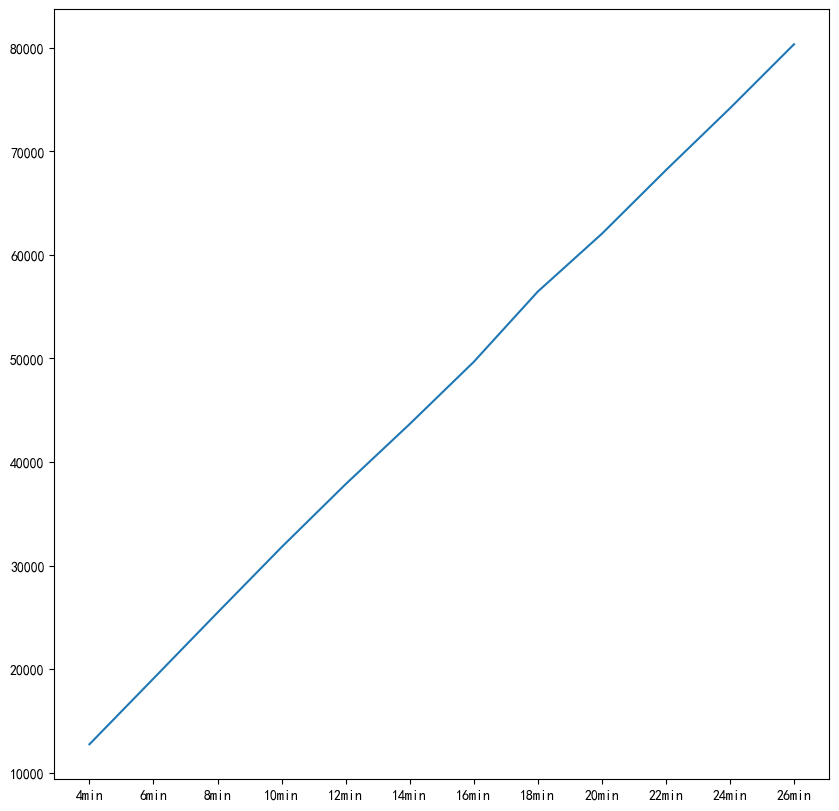

In [19]:
plt.figure(figsize=(10, 10))
plt.plot(T.index,T.values)

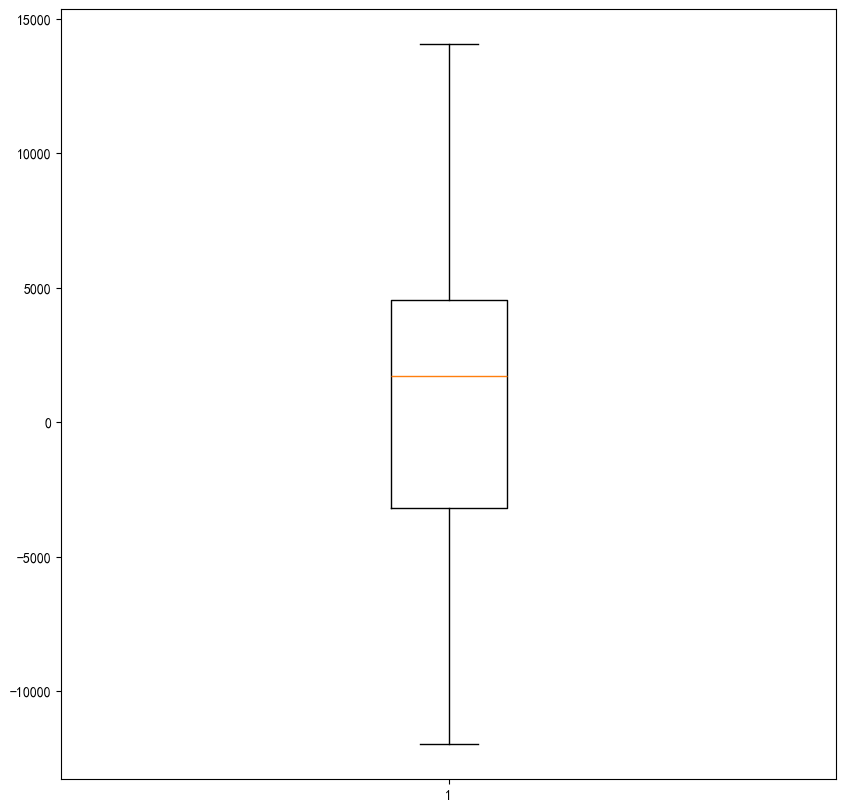

In [20]:
plt.figure(figsize=(10, 10))
plt.boxplot(df['gold_diff'])
plt.show()

### 3.2 检查推塔 / 击杀分布

In [ ]:
# ═══════════════════════════════════════════════════════════════
# 决策点 3.2：验证推塔/击杀 — "模拟出来的值有没有荒谬的？"
# ═══════════════════════════════════════════════════════════════
#
# 💡 需要检查的常识：
#
# 1. 4 分钟时推塔数应接近 0 — 王者荣耀前期很难推塔（一塔血很厚）
#    如果你的数据显示 4 分钟平均推了 2 座塔，那 α 参数可能设太小了
#
# 2. 击杀总数应该随时间递增 — 时间越长，打的团越多
#
# 3. 推塔的最大值别太离谱 — 4 分钟不可能推掉 5 座塔
#
# 这些检查的目的不是"让数据好看"，而是确认你的 α 参数设置合理。
# 如果验证发现问题，应该回去调 ALPHA["tower"] 的值。
# ═══════════════════════════════════════════════════════════════
# 你来写代码

In [ ]:
T = df.groupby('minute_bin')['c1_tower'].mean().sort_values()

In [ ]:
T

minute_bin
4min     0.708661
6min     1.246032
8min     1.833333
10min    2.385246
12min    2.876190
14min    3.194030
16min    3.742857
18min    4.526316
24min    4.666667
20min    5.000000
26min    5.333333
22min    5.500000
Name: c1_tower, dtype: float64

### 3.3 检查获胜方是否倾向于经济领先

如果模拟数据合理，在 10min 快照中，最终获胜方的经济应该**倾向**领先（但不绝对，因为翻盘也存在——虽然我们的模拟数据不会产生翻盘）。

In [ ]:
# ═══════════════════════════════════════════════════════════════
# 决策点 3.3：最关键的验证 — "获胜方确实经济领先吗？"
# ═══════════════════════════════════════════════════════════════
#
# 💡 为什么这一步最重要？
#
# 如果模拟数据里"获胜方经济领先"的比例不高于 50%，
# 那后面训练出来的模型就学不到"经济领先 → 容易赢"这个信号。
#
# 思维过程：
#   gold_diff = camp1_gold - camp2_gold
#   如果 camp1 赢（win_camp=1），那 gold_diff > 0 意味着"赢的那方确实领先"
#   如果 camp2 赢（win_camp=2），那 gold_diff < 0 才意味着"赢的那方领先"
#
#   统一视角：构造 winner_gold_lead 列，把经济差转换到"获胜方的视角"
#
# ⚠️ 模拟数据的一个已知缺陷：
#   由于我们的模拟是按终局比例插值，如果最终 camp1 经济高且赢了，
#   那它在所有时间点都会经济领先——不会出现"翻盘"模式。
#   这意味着模拟数据里获胜方经济领先的比例会**异常高**（接近 100%）。
#   这是正常的，但你要意识到：真实数据不会这么完美。
#
# 📌 验证锚点：获胜方经济领先占比应明显 > 50%（模拟数据中可能 > 80%）
# ═══════════════════════════════════════════════════════════════

# 你来写代码

---
## 步骤 4 · 保存模拟快照

保存到 `data/realtime/simulated_snapshots.csv`，后续 notebook 08 直接读这个文件来训练赛中胜率模型。

In [ ]:
# ═══════════════════════════════════════════════════════════════
# 步骤 4：保存 — 为什么要"写入→读回→验证"三步走？
# ═══════════════════════════════════════════════════════════════
#
# 💡 工程思维：数据落盘后一定要读回来验证
#
# 新手常犯的错：写了 to_csv 就觉得完事了。但 CSV 写入可能：
#   - 编码不对（中文变乱码）
#   - 浮点精度丢失
#   - index 被多存了一列
#   - 列名有隐藏空格
#
# 所以养成习惯：保存后立刻 read_csv 回来，确认 shape 和 dtypes 正确。
#
# 保存路径：REALTIME_DIR / "simulated_snapshots.csv"
# 这个文件是 notebook 08 的直接输入——如果这里有问题，08 会全部崩掉。
# ═══════════════════════════════════════════════════════════════

# 你来写代码

---
## 步骤 5 · Track B：真实赛中采集（直播时使用）

### 原理回顾

在之前的探索中我们发现了一个关键事实：

> **比赛直播期间，`battle/open?battle_id=xxx` 接口返回的数据是实时变化的！**
> 
> 经济、人头、推塔等字段会随着比赛进行不断更新，而不是等比赛结束才有数据。

这意味着：只要在比赛直播时，每隔 30 秒调一次这个接口，就能得到真实的赛中快照序列。

### 采集流程设计

```
1. 输入 battle_id
2. 循环：
   a. 调 API 获取当前数据
   b. 保存原始 JSON（用于回溯 debug）
   c. 解析为快照行
   d. 追加到 CSV
   e. 打印当前状态（经济差、人头差）
   f. sleep 30 秒
   g. 如果比赛已结束（status=2），停止
```

### ⚠️ 重要提醒

- Track B 代码现在**不需要运行**，它是为下次比赛直播准备的
- 运行前需要先确认有正在进行的比赛，并拿到 `battle_id`
- `game_duration` 在 API 原始 JSON 中是**毫秒**，需要除以 1000 转换为秒

In [ ]:
import json
import time
import random
import requests
from datetime import datetime


# ═══════════════════════════════════════════════════════════════
# 决策点 5.1：Track B 采集设计 — "直播时怎么拿到实时数据？"
# ═══════════════════════════════════════════════════════════════
#
# 💡 核心设计问题：
#
# 你已经知道 battle/open API 在比赛直播时会返回实时数据。
# 现在需要设计两个函数：
#
# ---- 函数 1：fetch_battle_live(battle_id) → dict | None ----
# 职责：安全地调一次 API，拿到原始 JSON
# 设计考虑：
#   - 网络不稳定怎么办？→ 重试机制（指数退避：2^attempt 秒 + 随机扰动）
#   - API 返回异常怎么办？→ 返回 None，让调用方决定如何处理
#   - 超时怎么办？→ timeout 参数 + catch Timeout 异常
#   单一职责：这个函数只负责"安全拿数据"，不负责"解析数据"
#
# ---- 函数 2：parse_live_snapshot(raw_json, collected_at) → dict ----
# 职责：从 API JSON 提取字段，对齐到 SNAPSHOT_COLS 格式
# 两个坑：
#   - API 的 game_duration 单位是毫秒！必须 /1000 转秒
#   - 输出格式必须和 Track A 完全一致——下游 notebook 08 不改代码
#
# ---- 面试怎么讲 ----
# "采集模块遵循单一职责：fetch 管网络 IO 和重试，parse 管数据解析。
#  两个 Track 输出 schema 统一，下游建模零改动——这是双轨方案的核心价值。"
#
# ⚠️ 这段代码现在不需要运行，等有直播时才用
# ═══════════════════════════════════════════════════════════════
#
# 代码提醒：
#
# API_URL = "https://app.kingglory.com/match/battle/open"
# HEADERS = {"User-Agent": "Mozilla/5.0 ..."}
#
# def fetch_battle_live(battle_id: str, max_retries: int = 3) -> dict | None:
#     """安全调一次 API，返回 JSON dict 或 None"""
#     for attempt in range(max_retries):
#         try:
#             resp = requests.get(
#                 API_URL, params={"battle_id": battle_id},
#                 headers=HEADERS, timeout=10
#             )
#             if resp.status_code == 200:
#                 data = resp.json()
#                 if data.get("result") == 0:  # API 约定：0 表示成功
#                     return data.get("data", {})
#             return None
#         except (requests.Timeout, requests.ConnectionError):
#             wait = (2 ** attempt) + random.uniform(0, 1)
#             print(f"  重试 {attempt+1}/{max_retries}，等待 {wait:.1f}s...")
#             time.sleep(wait)
#     return None
#
#
# def parse_live_snapshot(raw: dict, battle_id: str) -> dict:
#     """从 API JSON 解析出一行快照，格式对齐 SNAPSHOT_COLS"""
#     game_sec = raw.get("game_duration", 0) / 1000  # 毫秒→秒！
#     # 找到最接近的 minute_bin
#     minute_bin = None
#     for label, sec in TIME_BINS.items():
#         if abs(game_sec - sec) < 60:
#             minute_bin = label; break
#     if minute_bin is None:
#         minute_bin = f"{int(game_sec//60)}min"
#
#     camp1 = raw.get("camp1_info", {})
#     camp2 = raw.get("camp2_info", {})
#     return {
#         "battle_id": battle_id,
#         "snapshot_time_sec": int(game_sec),
#         "minute_bin": minute_bin,
#         "camp1_gold": camp1.get("gold", 0),
#         "camp2_gold": camp2.get("gold", 0),
#         "gold_diff": camp1.get("gold", 0) - camp2.get("gold", 0),
#         "camp1_kill_num": camp1.get("kill_num", 0),
#         "camp2_kill_num": camp2.get("kill_num", 0),
#         "kill_diff": camp1.get("kill_num", 0) - camp2.get("kill_num", 0),
#         "camp1_push_tower_num": camp1.get("push_tower_num", 0),
#         "camp2_push_tower_num": camp2.get("push_tower_num", 0),
#         "tower_diff": camp1.get("push_tower_num", 0) - camp2.get("push_tower_num", 0),
#         "camp1_tyrant": camp1.get("kill_tyrant_num", 0),
#         "camp2_tyrant": camp2.get("kill_tyrant_num", 0),
#         "win_camp": None,  # 比赛未结束时为 None
#         "is_simulated": False,
#     }

# 你来写代码

In [ ]:
def fetch_battle_live (
	battle_id: str,
    interval_sec: int = 30,
    max_duration_sec: int = 1800,
    output_dir: str | Path = "data/realtime/raw_snapshots",
):
	OUTPUT_DIR = Path()




In [ ]:
# ═══════════════════════════════════════════════════════════════
# 决策点 5.2：采集主循环 — "怎样在比赛直播时持续拿数据？"
# ═══════════════════════════════════════════════════════════════
#
# 💡 设计问题：collect_live_snapshots(battle_id, interval_sec, max_rounds)
#
# 这个函数要做的事情很直觉：
#   while 比赛没结束:
#       调 API → 保存 → 等 30 秒 → 再调
#
# 但细节决定质量：
#
# ---- 决策 1：采集频率设多少？ ----
# 太频繁（5秒）：可能触发反爬、也没必要（比赛局势不会 5 秒变一次）
# 太稀疏（5分钟）：会错过关键团战节点
# 30 秒是比较合理的折中——一场 15 分钟比赛能拿到约 30 个快照点
#
# ---- 决策 2：原始 JSON 要不要存？ ----
# 答案：必须存。万一 parse 逻辑有 bug，你还能从原始 JSON 重新解析。
# 存到 REALTIME_DIR / "raw_snapshots" / battle_id / "{timestamp}.json"
#
# ---- 决策 3：怎么判断比赛结束？ ----
# API 返回的 status == 2 表示比赛已结束。检测到后 break。
# 但如果网络断了拿不到数据呢？→ max_rounds 作为安全阀，防止死循环
#
# ---- 决策 4：CSV 追加还是覆盖？ ----
# 追加（mode="a"）——因为你可能连续采集多场比赛，都存在同一个文件里
#
# ⚠️ 这段代码现在不需要运行
# ═══════════════════════════════════════════════════════════════

# 你来写代码

### 如何使用 Track B？

当 KPL 有比赛直播时，按以下步骤操作：

1. 打开 KPL 官网或王者荣耀电竞页面，找到正在进行的比赛
2. 从 URL 或赛程数据中获取 `battle_id`
3. 运行下面的 cell（取消注释）
4. 采集会自动进行，比赛结束后自动停止

```python
# ⚠️ 仅在有直播比赛时取消注释运行！
# live_battle_id = "736117264_10_1777089898"  # 替换为实际的 battle_id
# collected = collect_live_snapshots(live_battle_id, interval_sec=30)
```

In [ ]:
# ======================================================
# ⚠️ 仅在有直播比赛时取消注释运行！
# ======================================================
# live_battle_id = "736117264_10_1777089898"  # ← 替换为当前直播的 battle_id
# collected = collect_live_snapshots(live_battle_id, interval_sec=30)

---
## 步骤 6 · 总结报告

### 本 notebook 完成了什么？

| 产出 | 说明 |
|------|------|
| `data/realtime/simulated_snapshots.csv` | Track A 模拟快照，127 场比赛 × 最多 4 个时间点 |
| `collect_live_snapshots()` 函数 | Track B 真实采集代码，直播时运行 |
| 快照 Schema | 统一的建模数据格式，08/09 直接消费 |

### 数据流转图

```
battles.csv (赛后) ──→ Track A: simulate ──→ simulated_snapshots.csv
                                                        │
battle/open API ──→ Track B: live collect ──→ live_snapshots.csv
                                                        │
                                          ┌─────────────┘
                                          ▼
                               notebook 08: 实时胜率建模
                                          │
                                          ▼
                               notebook 09: Dashboard 演示
```

### 模拟 vs 真实数据的使用策略

- **当前阶段**：先用 Track A 模拟数据跑通 08/09 全流程
- **采集积累后**：用 Track B 真实数据重新训练，模型效果会更好
- **混合训练**：也可以把两种数据拼在一起训练，`is_simulated` 列可以作为额外特征告诉模型数据来源

### 面试话术建议

> "赛中实时预测的核心挑战是数据采集——比赛进行中的快照数据无法回溯。
> 我设计了双轨方案：Track A 基于赛后终局数据用幂律插值模拟历史快照，
> 用于模型冷启动和全链路验证；Track B 在比赛直播时通过赛事 API 每 30 秒
> 轮询采集真实快照。两个 track 输出的数据格式完全一致，下游建模代码无需修改。"

---
## ✅ 完成自检

运行完本 notebook 后，逐项确认：

- [ ] Step 0：导包无报错，路径正确
- [ ] Step 2：`df_sim` 生成成功，行数 ≈ 127 × 4 = 508（实际会少一些，因为部分比赛时长不足 10 分钟）
- [ ] Step 3.1：经济趋势图显示递增，符合直觉
- [ ] Step 3.2：3 分钟推塔数接近 0
- [ ] Step 3.3：获胜方经济领先比例 > 50%
- [ ] Step 4：`data/realtime/simulated_snapshots.csv` 已生成，读回无异常
- [ ] Step 5：Track B 代码已就绪（但未运行），等待下次直播使用

### 下一步

→ 打开 `08_实时胜率建模V4.ipynb`，用 `simulated_snapshots.csv` 训练赛中胜率预测模型